# SLA Score Prediction System
## Machine Learning Model for SLA Breach Prediction

This notebook predicts SLA breaches using machine learning on incident data.

**Data Source:** fact_sla_predictions.csv (30 incidents)

**Goal:** Predict which incidents will breach SLA targets

## Setup: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score, roc_auc_score, roc_curve
)
import warnings
warnings.filterwarnings('ignore')

print('✓ All libraries imported successfully!')

✓ All libraries imported successfully!


## Step 1: Load Data

In [2]:
# Load the CSV file
df = pd.read_csv(r"C:\Users\272749\Downloads\fact_sla_predictions_synthetic_1000.csv")

print(f'✓ Loaded {len(df)} incidents')
print(f'✓ Loaded {len(df.columns)} columns')
print(f'\nDataframe shape: {df.shape}')
print(f'\nFirst 5 rows:')
df.head()

✓ Loaded 1000 incidents
✓ Loaded 36 columns

Dataframe shape: (1000, 36)

First 5 rows:


,sla_id,alert_id,fingerprint,customer_key,customer_name,alert_type_key,alert_name,alert_category,device_key,device_name,...,day_of_week,day_of_month,month,year,is_weekend,is_business_hours,num_related_alerts,severity_level,data_quality_score,is_valid_for_prediction
0,1,85214915-22b1-4a6e-9556-ebf1067da452,fp_000001_2278548,7,Ocean Point Terminals (LTB),5,Internet Connection is Lost,service,7,DC3,...,0,25,5,2026,False,False,1,P3,1.0,True
1,2,42a8a6ff-a76f-4fd7-900e-c9092fc7d9e0,fp_000002_3158281,9,Wyffels,14,Windows Event Log,server,6,DMG-SLO-AP02,...,4,29,5,2026,False,False,6,P2,1.0,True
2,3,6d8c0fb1-8c7c-4816-b40e-4b6db22d34d7,fp_000003_8952785,2,Ambient Enterprises - Johnson Barrow,5,Internet Connection is Lost,service,5,dpOBTlabsw01,...,2,29,4,2026,False,True,4,P3,1.0,True
3,4,050fa547-cf45-4db0-b2ed-542721368de0,fp_000004_8009976,9,Wyffels,7,Network Element Offline,device,2,dyo-sch-fw01a,...,2,1,4,2026,False,False,1,P2,1.0,True
4,5,79806743-bd97-431f-933d-93ecfce6c84d,fp_000005_4836496,5,HVP SLHV Data Center,14,Windows Event Log,server,2,dyo-sch-fw01a,...,3,26,3,2026,False,False,6,P2,1.0,True


In [3]:
# Display basic info
print('Data types:')
print(df.dtypes)
print(f'\nMissing values: {df.isnull().sum().sum()}')

Data types:
sla_id                             int64
alert_id                          object
fingerprint                       object
customer_key                       int64
customer_name                     object
alert_type_key                     int64
alert_name                        object
alert_category                    object
device_key                         int64
device_name                       object
source_key                         int64
source_system                     object
alert_created_at                  object
alert_acknowledged_at             object
alert_resolved_at                 object
response_time_minutes            float64
resolution_time_minutes          float64
sla_response_target_minutes        int64
sla_resolution_target_minutes      int64
response_meets_sla                  bool
resolution_meets_sla                bool
overall_sla_met                     bool
sla_breach_flag                    int64
minutes_over_response_sla        float64
minu

## Step 2: Exploratory Data Analysis (EDA)

### 2.1: Overall SLA Score

CURRENT SLA SCORES
Total Incidents:        1000
SLA Met:                274 (27.4%)
SLA Breached:           726 (72.6%)
Overall SLA Score:      27.40%


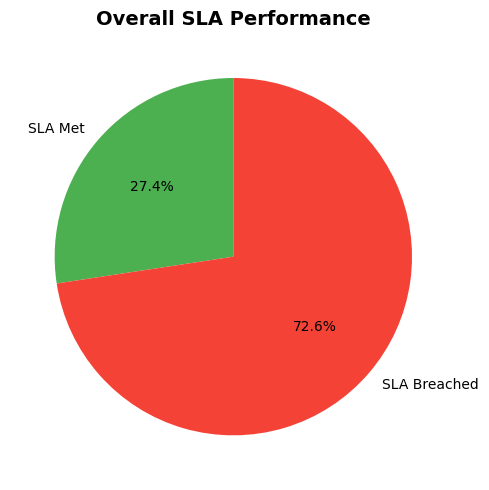

In [4]:
# Calculate overall SLA metrics
overall_sla_met = (df['sla_breach_flag'] == 0).sum()
overall_sla_breached = (df['sla_breach_flag'] == 1).sum()
overall_sla_score = (overall_sla_met / len(df)) * 100

print('='*60)
print('CURRENT SLA SCORES')
print('='*60)
print(f'Total Incidents:        {len(df)}')
print(f'SLA Met:                {overall_sla_met} ({(overall_sla_met/len(df))*100:.1f}%)')
print(f'SLA Breached:           {overall_sla_breached} ({(overall_sla_breached/len(df))*100:.1f}%)')
print(f'Overall SLA Score:      {overall_sla_score:.2f}%')

# Visualization
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
labels = ['SLA Met', 'SLA Breached']
sizes = [overall_sla_met, overall_sla_breached]
colors = ['#4CAF50', '#F44336']
ax.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
ax.set_title('Overall SLA Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.2: SLA Score by Customer

SLA SCORE BY CUSTOMER
                                                     Total  Met  SLA_Score_%
customer_name                                                               
Ambient Enterprises                                     87   30         34.5
HVP SLHV Data Center                                    96   32         33.3
Ambient Enterprises - Johnson Barrow                    98   29         29.6
Ambient Enterprises DMG San Luis Obispo                 76   22         28.9
Wedgewood Pharmacy                                      94   26         27.7
Hanover Company Azure                                  102   28         27.5
Ocean Point Terminals (LTB)                             89   23         25.8
Wyffels                                                 83   21         25.3
Signorelli Company                                      95   23         24.2
DYOPATH Oakbrook Terrace                                79   18         22.8
Ambient Enterprises > Ambient Enterprises HCN (HAR)   

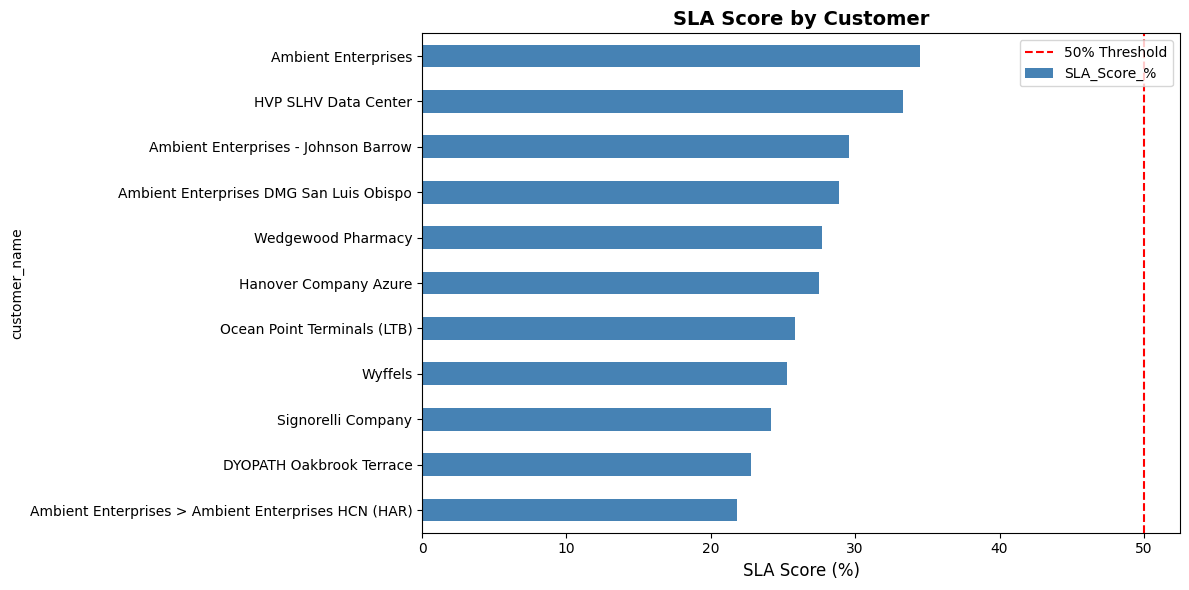

In [5]:
# SLA by Customer
customer_sla = df.groupby('customer_name').agg({
    'sla_breach_flag': ['count', lambda x: (x == 0).sum()]
}).round(2)

customer_sla.columns = ['Total', 'Met']
customer_sla['SLA_Score_%'] = (customer_sla['Met'] / customer_sla['Total'] * 100).round(1)
customer_sla = customer_sla.sort_values('SLA_Score_%', ascending=False)

print('SLA SCORE BY CUSTOMER')
print('='*60)
print(customer_sla.to_string())

# Visualization
fig, ax = plt.subplots(figsize=(12, 6))
customer_sla['SLA_Score_%'].sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.axvline(x=50, color='red', linestyle='--', label='50% Threshold')
ax.set_xlabel('SLA Score (%)', fontsize=12)
ax.set_title('SLA Score by Customer', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### 2.3: SLA Score by Alert Category

SLA SCORE BY ALERT CATEGORY
                Total  Met  Avg_Response  Avg_Resolution  SLA_Score_%
alert_category                                                       
device            142   47         43.56          468.33         33.1
network           270   79         14.61          121.83         29.3
server            392  102         29.38          233.76         26.0
service           138   33         20.73          175.04         23.9
interface          58   13         29.87          241.59         22.4


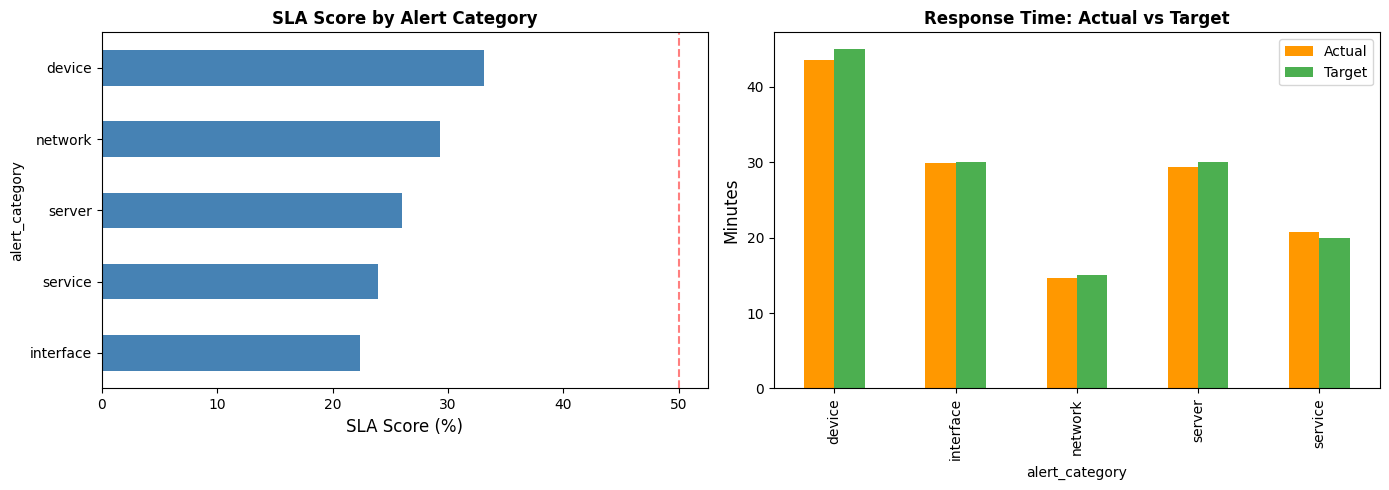

In [6]:
# SLA by Alert Category
category_sla = df.groupby('alert_category').agg({
    'sla_breach_flag': ['count', lambda x: (x == 0).sum()],
    'response_time_minutes': 'mean',
    'resolution_time_minutes': 'mean'
}).round(2)

category_sla.columns = ['Total', 'Met', 'Avg_Response', 'Avg_Resolution']
category_sla['SLA_Score_%'] = (category_sla['Met'] / category_sla['Total'] * 100).round(1)
category_sla = category_sla.sort_values('SLA_Score_%', ascending=False)

print('SLA SCORE BY ALERT CATEGORY')
print('='*70)
print(category_sla.to_string())

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# SLA Score
category_sla['SLA_Score_%'].sort_values().plot(kind='barh', ax=ax1, color='steelblue')
ax1.set_xlabel('SLA Score (%)', fontsize=12)
ax1.set_title('SLA Score by Alert Category', fontsize=12, fontweight='bold')
ax1.axvline(x=50, color='red', linestyle='--', alpha=0.5)

# Response Time vs Target
response_comparison = pd.DataFrame({
    'Actual': category_sla['Avg_Response'],
    'Target': df.groupby('alert_category')['sla_response_target_minutes'].first()
})
response_comparison.plot(kind='bar', ax=ax2, color=['#FF9800', '#4CAF50'])
ax2.set_ylabel('Minutes', fontsize=12)
ax2.set_title('Response Time: Actual vs Target', fontsize=12, fontweight='bold')
ax2.legend(['Actual', 'Target'])
plt.tight_layout()
plt.show()

### 2.4: SLA Score by Severity Level

SLA SCORE BY SEVERITY LEVEL
                Total  Met  Avg_Response  SLA_Score_%
severity_level                                       
P4                 61   33          7.75         54.1
P3                591  205         19.92         34.7
P2                330   36         38.79         10.9
P1                 18    0         66.47          0.0


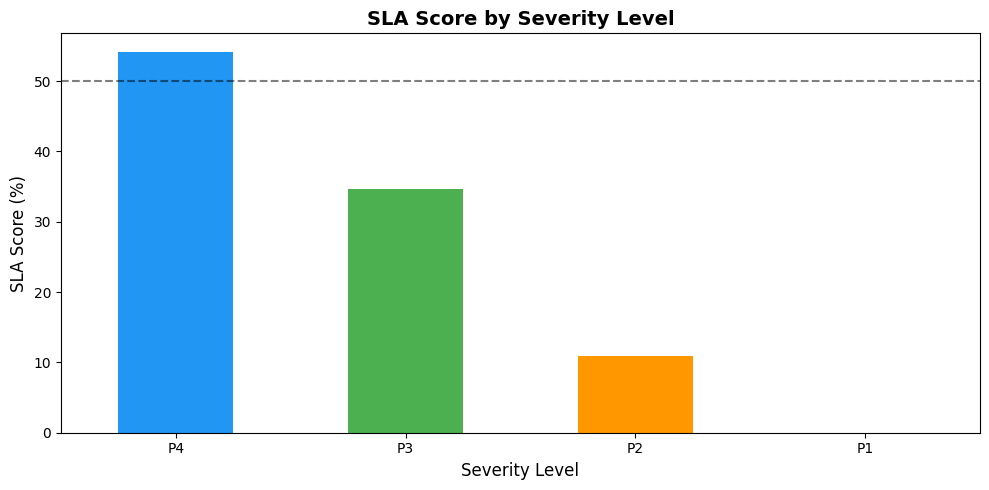

In [7]:
# SLA by Severity
severity_sla = df.groupby('severity_level').agg({
    'sla_breach_flag': ['count', lambda x: (x == 0).sum()],
    'response_time_minutes': 'mean'
}).round(2)

severity_sla.columns = ['Total', 'Met', 'Avg_Response']
severity_sla['SLA_Score_%'] = (severity_sla['Met'] / severity_sla['Total'] * 100).round(1)
severity_sla = severity_sla.sort_values('SLA_Score_%', ascending=False)

print('SLA SCORE BY SEVERITY LEVEL')
print('='*60)
print(severity_sla.to_string())

# Visualization
fig, ax = plt.subplots(figsize=(10, 5))
colors_severity = {'P1': '#F44336', 'P2': '#FF9800', 'P3': '#4CAF50'}
color_list = [colors_severity.get(x, '#2196F3') for x in severity_sla.index]
severity_sla['SLA_Score_%'].plot(kind='bar', ax=ax, color=color_list)
ax.axhline(y=50, color='black', linestyle='--', alpha=0.5)
ax.set_ylabel('SLA Score (%)', fontsize=12)
ax.set_xlabel('Severity Level', fontsize=12)
ax.set_title('SLA Score by Severity Level', fontsize=14, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

## Step 3: Prepare Data for ML Model

In [8]:
# Select features for prediction
feature_columns = [
    'customer_key', 'alert_type_key', 'device_key', 'source_key',
    'response_time_minutes', 'resolution_time_minutes',
    'sla_response_target_minutes', 'sla_resolution_target_minutes',
    'alert_hour', 'day_of_week', 'day_of_month', 'month',
    'is_weekend', 'is_business_hours', 'num_related_alerts'
]

# Target variable
target = 'sla_breach_flag'  # 0 = MET, 1 = BREACH

X = df[feature_columns].copy()
y = df[target].copy()

# Convert boolean to int
X['is_weekend'] = X['is_weekend'].astype(int)
X['is_business_hours'] = X['is_business_hours'].astype(int)

print('='*60)
print('DATA PREPARATION')
print('='*60)
print(f'Features: {len(feature_columns)}')
print(f'Training samples: {len(X)}')
print(f'Target variable: {target}')
print(f'\nTarget distribution:')
print(f'  SLA Met (0):     {(y==0).sum()} incidents')
print(f'  SLA Breach (1):  {(y==1).sum()} incidents')
print(f'\nFeatures:')
for i, col in enumerate(feature_columns, 1):
    print(f'  {i:2d}. {col}')

DATA PREPARATION
Features: 15
Training samples: 1000
Target variable: sla_breach_flag

Target distribution:
  SLA Met (0):     274 incidents
  SLA Breach (1):  726 incidents

Features:
   1. customer_key
   2. alert_type_key
   3. device_key
   4. source_key
   5. response_time_minutes
   6. resolution_time_minutes
   7. sla_response_target_minutes
   8. sla_resolution_target_minutes
   9. alert_hour
  10. day_of_week
  11. day_of_month
  12. month
  13. is_weekend
  14. is_business_hours
  15. num_related_alerts


## Step 4: Train ML Model

In [9]:
# Split data (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('='*60)
print('TRAIN/TEST SPLIT')
print('='*60)
print(f'Training samples: {len(X_train)}')
print(f'Testing samples:  {len(X_test)}')
print(f'Training target distribution:')
print(f'  SLA Met (0):     {(y_train==0).sum()}')
print(f'  SLA Breach (1):  {(y_train==1).sum()}')

TRAIN/TEST SPLIT
Training samples: 800
Testing samples:  200
Training target distribution:
  SLA Met (0):     219
  SLA Breach (1):  581


In [10]:
# Train Random Forest model
print('Training Random Forest model...')

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
print('✓ Model trained successfully!')

Training Random Forest model...
✓ Model trained successfully!


## Step 5: Model Evaluation

In [11]:
# Make predictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print('='*60)
print('MODEL EVALUATION METRICS')
print('='*60)
print(f'Accuracy:     {accuracy:.3f} ({accuracy*100:.1f}%)')
print(f'Precision:    {precision:.3f} ({precision*100:.1f}%)')
print(f'Recall:       {recall:.3f} ({recall*100:.1f}%)')
print(f'F1 Score:     {f1:.3f}')
print(f'ROC-AUC:      {roc_auc:.3f}')

MODEL EVALUATION METRICS
Accuracy:     0.920 (92.0%)
Precision:    0.901 (90.1%)
Recall:       1.000 (100.0%)
F1 Score:     0.948
ROC-AUC:      0.973


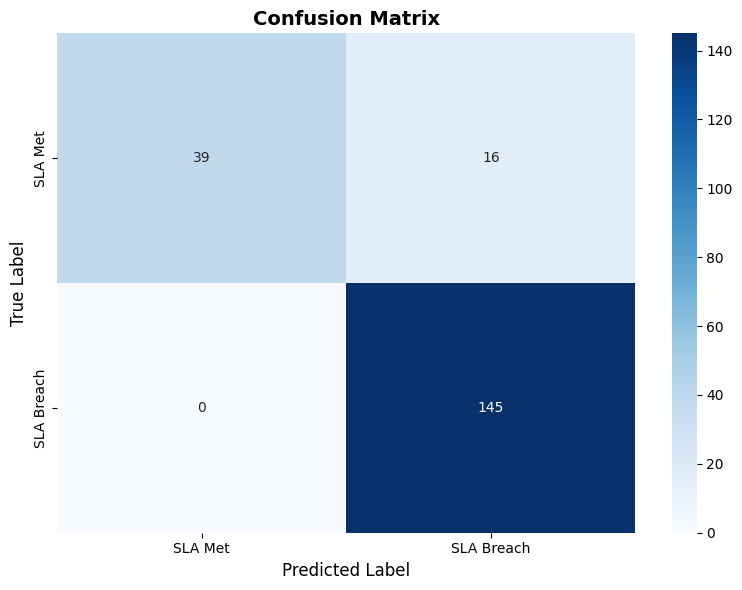


Confusion Matrix Details:
True Negatives (Correct MET):        39
False Positives (Wrong BREACH):      16
False Negatives (Wrong MET):         0
True Positives (Correct BREACH):     145


In [12]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['SLA Met', 'SLA Breach'],
            yticklabels=['SLA Met', 'SLA Breach'])
ax.set_ylabel('True Label', fontsize=12)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nConfusion Matrix Details:')
print(f'True Negatives (Correct MET):        {cm[0,0]}')
print(f'False Positives (Wrong BREACH):      {cm[0,1]}')
print(f'False Negatives (Wrong MET):         {cm[1,0]}')
print(f'True Positives (Correct BREACH):     {cm[1,1]}')

In [13]:
# Classification Report
print('\nClassification Report:')
print(classification_report(y_test, y_pred, 
    target_names=['SLA Met (0)', 'SLA Breach (1)']))


Classification Report:
                precision    recall  f1-score   support

   SLA Met (0)       1.00      0.71      0.83        55
SLA Breach (1)       0.90      1.00      0.95       145

      accuracy                           0.92       200
     macro avg       0.95      0.85      0.89       200
  weighted avg       0.93      0.92      0.92       200



## Step 6: Feature Importance


TOP 10 FEATURE IMPORTANCE
                      Feature  Importance
      resolution_time_minutes    0.252656
        response_time_minutes    0.235675
  sla_response_target_minutes    0.062123
                 day_of_month    0.059032
                   alert_hour    0.053050
               alert_type_key    0.051851
                   device_key    0.051486
sla_resolution_target_minutes    0.050254
           num_related_alerts    0.046020
                 customer_key    0.044391


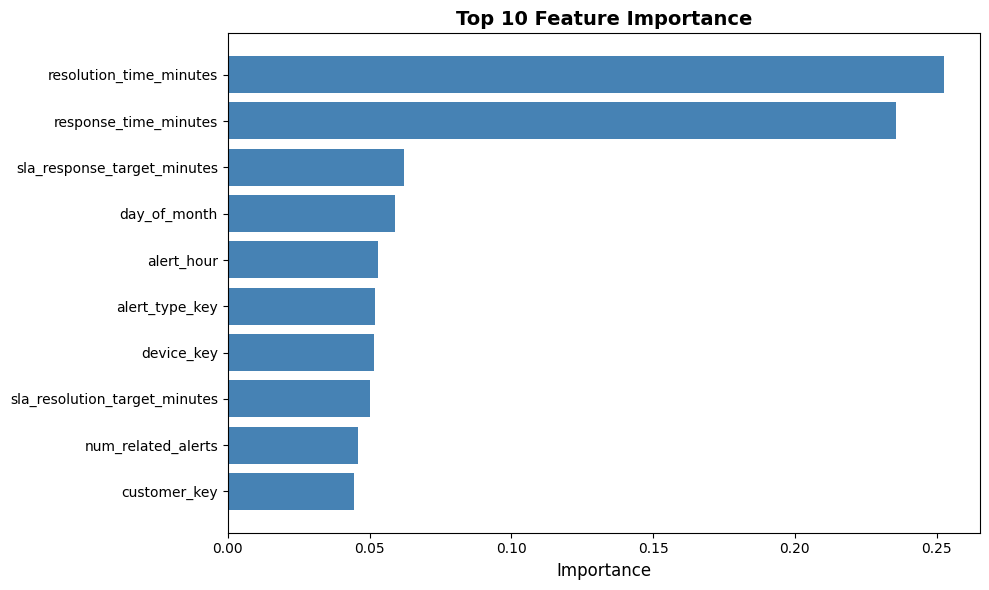

In [14]:
# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print('\nTOP 10 FEATURE IMPORTANCE')
print('='*60)
print(feature_importance.head(10).to_string(index=False))

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
top_10 = feature_importance.head(10)
ax.barh(range(len(top_10)), top_10['Importance'].values, color='steelblue')
ax.set_yticks(range(len(top_10)))
ax.set_yticklabels(top_10['Feature'].values)
ax.set_xlabel('Importance', fontsize=12)
ax.set_title('Top 10 Feature Importance', fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Step 7: Predict on Full Data

In [15]:
# Predict on full dataset
y_pred_all = model.predict(X)
y_pred_proba_all = model.predict_proba(X)[:, 1]

# Add predictions to dataframe
df['predicted_breach_flag'] = y_pred_all
df['breach_probability'] = y_pred_proba_all

# Accuracy on full data
full_accuracy = accuracy_score(y, y_pred_all)

print('='*60)
print('PREDICTIONS ON FULL DATA')
print('='*60)
print(f'Model accuracy on all data: {full_accuracy:.3f} ({full_accuracy*100:.1f}%)')
print(f'\nFirst 10 predictions:')
print(df[['sla_id', 'customer_name', 'alert_category', 'sla_breach_flag', 
          'predicted_breach_flag', 'breach_probability']].head(10).to_string(index=False))

PREDICTIONS ON FULL DATA
Model accuracy on all data: 0.984 (98.4%)

First 10 predictions:
 sla_id                                       customer_name alert_category  sla_breach_flag  predicted_breach_flag  breach_probability
      1                         Ocean Point Terminals (LTB)        service                1                      1            0.886709
      2                                             Wyffels         server                1                      1            0.980715
      3                Ambient Enterprises - Johnson Barrow        service                1                      1            0.889101
      4                                             Wyffels         device                1                      1            0.811680
      5                                HVP SLHV Data Center         server                1                      1            0.785273
      6                                 Ambient Enterprises         device                1         

## Step 8: Identify At-Risk Incidents

In [16]:
# Find high-risk incidents
at_risk = df[df['breach_probability'] > 0.5].sort_values(
    'breach_probability', ascending=False
)

print('='*60)
print('AT-RISK INCIDENTS (Breach Probability > 50%)')
print('='*60)
print(f'Total at-risk incidents: {len(at_risk)}')

# Display top 10
at_risk_display = at_risk[['sla_id', 'customer_name', 'alert_category', 
                             'response_time_minutes', 'sla_response_target_minutes',
                             'breach_probability']].head(10)
print('\nTop 10 At-Risk Incidents:')
print(at_risk_display.to_string(index=False))

AT-RISK INCIDENTS (Breach Probability > 50%)
Total at-risk incidents: 742

Top 10 At-Risk Incidents:
 sla_id                                       customer_name alert_category  response_time_minutes  sla_response_target_minutes  breach_probability
    902 Ambient Enterprises > Ambient Enterprises HCN (HAR)        network                  15.90                           15            0.999656
    661             Ambient Enterprises DMG San Luis Obispo         server                  32.51                           30            0.998874
    534                                  Signorelli Company         server                  36.66                           30            0.998133
    987                            DYOPATH Oakbrook Terrace         server                  43.23                           30            0.997356
    864                                             Wyffels         server                  39.11                           30            0.996940
    291          

## Step 9: Customer Risk Assessment

CUSTOMER RISK ASSESSMENT
                                                     Avg_Breach_Probability  Total_Incidents  SLA_Met  Predicted_SLA_Score_%
customer_name                                                                                                               
Ambient Enterprises > Ambient Enterprises HCN (HAR)                   0.783              101       22                   21.7
DYOPATH Oakbrook Terrace                                              0.762               79       18                   23.8
Wyffels                                                               0.744               83       21                   25.6
Signorelli Company                                                    0.743               95       23                   25.7
Wedgewood Pharmacy                                                    0.739               94       26                   26.1
Ocean Point Terminals (LTB)                                           0.733               89       2

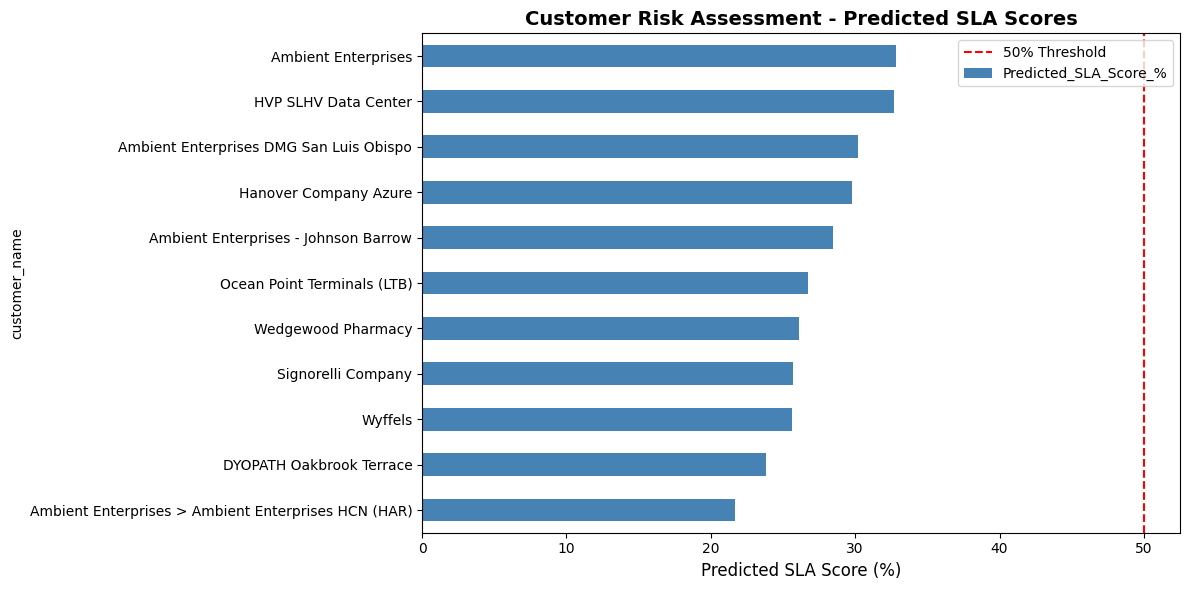

In [17]:
# Customer risk scores
customer_risk = df.groupby('customer_name').agg({
    'breach_probability': 'mean',
    'sla_breach_flag': ['count', lambda x: (x == 0).sum()]
}).round(3)

customer_risk.columns = ['Avg_Breach_Probability', 'Total_Incidents', 'SLA_Met']
customer_risk['Predicted_SLA_Score_%'] = (
    (1 - customer_risk['Avg_Breach_Probability']) * 100
).round(1)
customer_risk = customer_risk.sort_values('Avg_Breach_Probability', ascending=False)

print('='*80)
print('CUSTOMER RISK ASSESSMENT')
print('='*80)
print(customer_risk.to_string())

# Visualization
fig, ax = plt.subplots(figsize=(12, 6))
customer_risk['Predicted_SLA_Score_%'].sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.axvline(x=50, color='red', linestyle='--', label='50% Threshold')
ax.set_xlabel('Predicted SLA Score (%)', fontsize=12)
ax.set_title('Customer Risk Assessment - Predicted SLA Scores', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## Step 10: Predictions by Alert Category

In [18]:
# Category risk assessment
category_risk = df.groupby('alert_category').agg({
    'breach_probability': 'mean',
    'sla_breach_flag': ['count', lambda x: (x == 0).sum()]
}).round(3)

category_risk.columns = ['Avg_Breach_Probability', 'Total_Incidents', 'Current_SLA_Met']
category_risk['Current_SLA_Score_%'] = (
    (category_risk['Current_SLA_Met'] / category_risk['Total_Incidents']) * 100
).round(1)
category_risk['Predicted_SLA_Score_%'] = (
    (1 - category_risk['Avg_Breach_Probability']) * 100
).round(1)
category_risk['Difference_%'] = (
    category_risk['Predicted_SLA_Score_%'] - category_risk['Current_SLA_Score_%']
).round(1)

print('='*100)
print('ALERT CATEGORY RISK ASSESSMENT')
print('='*100)
print(category_risk.to_string())

ALERT CATEGORY RISK ASSESSMENT
                Avg_Breach_Probability  Total_Incidents  Current_SLA_Met  Current_SLA_Score_%  Predicted_SLA_Score_%  Difference_%
alert_category                                                                                                                    
device                           0.684              142               47                 33.1                   31.6          -1.5
interface                        0.760               58               13                 22.4                   24.0           1.6
network                          0.680              270               79                 29.3                   32.0           2.7
server                           0.749              392              102                 26.0                   25.1          -0.9
service                          0.767              138               33                 23.9                   23.3          -0.6


## Step 11: Save Predictions

In [19]:
# Save predictions to CSV
output_df = df[[
    'sla_id', 'customer_name', 'alert_category', 'alert_name',
    'response_time_minutes', 'resolution_time_minutes',
    'sla_breach_flag', 'predicted_breach_flag', 'breach_probability',
    'severity_level'
]].copy()

output_df = output_df.sort_values('breach_probability', ascending=False)
output_df.to_csv('sla_predictions_results.csv', index=False)

print('✓ Saved: sla_predictions_results.csv')
print(f'\nTop 10 predictions (by breach probability):')
print(output_df.head(10).to_string(index=False))

✓ Saved: sla_predictions_results.csv

Top 10 predictions (by breach probability):
 sla_id                                       customer_name alert_category                  alert_name  response_time_minutes  resolution_time_minutes  sla_breach_flag  predicted_breach_flag  breach_probability severity_level
    902 Ambient Enterprises > Ambient Enterprises HCN (HAR)        network Client IP conflict detected                  15.90                   249.70                1                      1            0.999656             P3
    661             Ambient Enterprises DMG San Luis Obispo         server                        Disk                  32.51                   361.44                1                      1            0.998874             P2
    534                                  Signorelli Company         server                Connectivity                  36.66                   393.74                1                      1            0.998133             P2
    987       

## Step 12: Key Recommendations

In [20]:
print('='*80)
print('KEY FINDINGS & RECOMMENDATIONS')
print('='*80)

# Finding 1: Worst customer
worst_customer = customer_risk.index[0]
worst_score = customer_risk.loc[worst_customer, 'Predicted_SLA_Score_%']
print(f'\n1. WORST PERFORMING CUSTOMER:')
print(f'   Customer: {worst_customer}')
print(f'   Predicted SLA Score: {worst_score:.1f}%')
print(f'   Action: Immediate intervention required')

# Finding 2: Worst category
worst_category = category_risk['Current_SLA_Score_%'].idxmin()
worst_cat_score = category_risk.loc[worst_category, 'Current_SLA_Score_%']
print(f'\n2. MOST PROBLEMATIC ALERT CATEGORY:')
print(f'   Category: {worst_category}')
print(f'   Current SLA Score: {worst_cat_score:.1f}%')
print(f'   Action: Add resources and automation')

# Finding 3: Breach patterns
print(f'\n3. MOST COMMON BREACH PATTERNS:')
breach_df = df[df['sla_breach_flag'] == 1].copy()
if len(breach_df) > 0:
    breach_cause = breach_df['alert_category'].value_counts()
    for i, (cat, count) in enumerate(breach_cause.head(3).items(), 1):
        pct = (count / len(breach_df)) * 100
        print(f'   {i}. {cat}: {count} incidents ({pct:.1f}% of breaches)')

# Finding 4: Response times
print(f'\n4. AVERAGE RESPONSE TIME BY CATEGORY:')
avg_response = df.groupby('alert_category')['response_time_minutes'].mean().sort_values(ascending=False)
for i, (cat, time) in enumerate(avg_response.head(3).items(), 1):
    target = df[df['alert_category'] == cat]['sla_response_target_minutes'].iloc[0]
    diff = time - target
    status = f'OVER by {diff:.1f} min' if diff > 0 else f'UNDER by {abs(diff):.1f} min'
    print(f'   {i}. {cat}: {time:.1f} min (target: {target} min) - {status}')

# Finding 5: Critical severity
p1_p2_breach = df[df['severity_level'].isin(['P1', 'P2'])]['sla_breach_flag'].sum()
p1_p2_total = len(df[df['severity_level'].isin(['P1', 'P2'])])
print(f'\n5. CRITICAL/HIGH PRIORITY INCIDENTS:')
print(f'   P1/P2 Breaches: {p1_p2_breach}/{p1_p2_total} ({(p1_p2_breach/p1_p2_total)*100:.0f}%)')
if p1_p2_breach == p1_p2_total:
    print(f'   ⚠️  ALL critical and high-priority incidents are BREACHING!')
    print(f'   Action: URGENT - Implement priority escalation process')

print('\n' + '='*80)

KEY FINDINGS & RECOMMENDATIONS

1. WORST PERFORMING CUSTOMER:
   Customer: Ambient Enterprises > Ambient Enterprises HCN (HAR)
   Predicted SLA Score: 21.7%
   Action: Immediate intervention required

2. MOST PROBLEMATIC ALERT CATEGORY:
   Category: interface
   Current SLA Score: 22.4%
   Action: Add resources and automation

3. MOST COMMON BREACH PATTERNS:
   1. server: 290 incidents (39.9% of breaches)
   2. network: 191 incidents (26.3% of breaches)
   3. service: 105 incidents (14.5% of breaches)

4. AVERAGE RESPONSE TIME BY CATEGORY:
   1. device: 43.6 min (target: 45 min) - UNDER by 1.4 min
   2. interface: 29.9 min (target: 30 min) - UNDER by 0.1 min
   3. server: 29.4 min (target: 30 min) - UNDER by 0.6 min

5. CRITICAL/HIGH PRIORITY INCIDENTS:
   P1/P2 Breaches: 312/348 (90%)



## Step 13: Summary & Next Steps

In [21]:
print('='*80)
print('SUMMARY')
print('='*80)

summary_text = f"""
📊 CURRENT STATE:
   • Overall SLA Score: {overall_sla_score:.1f}%
   • Incidents Met: {overall_sla_met}/{len(df)}
   • Incidents Breached: {overall_sla_breached}/{len(df)}

🤖 PREDICTION MODEL:
   • Algorithm: Random Forest Classifier
   • Accuracy: {accuracy*100:.1f}%
   • Precision: {precision*100:.1f}%
   • Recall: {recall*100:.1f}%
   • ROC-AUC: {roc_auc:.3f}
   • Training Samples: {len(X_train)}
   • Test Samples: {len(X_test)}

⚠️ AT-RISK INCIDENTS:
   • High risk (>50% breach probability): {len(at_risk)} incidents
   • Medium risk (20-50%): {len(df[(df['breach_probability'] >= 0.2) & (df['breach_probability'] <= 0.5)])} incidents
   • Low risk (<20%): {len(df[df['breach_probability'] < 0.2])} incidents

✅ FILES GENERATED:
   • sla_predictions_results.csv - Detailed predictions
   • This notebook - Complete analysis

🎯 NEXT STEPS:
   1. Share results with operations team
   2. Implement Priority 1 recommendations
   3. Deploy predictive alerting system
   4. Monitor and measure impact
   5. Retrain model monthly with new data
"""

print(summary_text)
print('='*80)
print('SLA PREDICTION ANALYSIS COMPLETE ✓')
print('='*80)

SUMMARY

📊 CURRENT STATE:
   • Overall SLA Score: 27.4%
   • Incidents Met: 274/1000
   • Incidents Breached: 726/1000

🤖 PREDICTION MODEL:
   • Algorithm: Random Forest Classifier
   • Accuracy: 92.0%
   • Precision: 90.1%
   • Recall: 100.0%
   • ROC-AUC: 0.973
   • Training Samples: 800
   • Test Samples: 200

⚠️ AT-RISK INCIDENTS:
   • High risk (>50% breach probability): 742 incidents
   • Medium risk (20-50%): 142 incidents
   • Low risk (<20%): 116 incidents

✅ FILES GENERATED:
   • sla_predictions_results.csv - Detailed predictions
   • This notebook - Complete analysis

🎯 NEXT STEPS:
   1. Share results with operations team
   2. Implement Priority 1 recommendations
   3. Deploy predictive alerting system
   4. Monitor and measure impact
   5. Retrain model monthly with new data

SLA PREDICTION ANALYSIS COMPLETE ✓


## Additional: Export Model for Future Use

In [22]:
import joblib

# Save the trained model
joblib.dump(model, 'sla_prediction_model.pkl')
print('✓ Saved model: sla_prediction_model.pkl')

# Save feature list for future predictions
joblib.dump(feature_columns, 'feature_columns.pkl')
print('✓ Saved features: feature_columns.pkl')

# Instructions for loading
print('''
To use the model in the future:

import joblib
model = joblib.load('sla_prediction_model.pkl')
features = joblib.load('feature_columns.pkl')

# Make predictions on new data
predictions = model.predict(X_new)
probabilities = model.predict_proba(X_new)[:, 1]
''')

✓ Saved model: sla_prediction_model.pkl
✓ Saved features: feature_columns.pkl

To use the model in the future:

import joblib
model = joblib.load('sla_prediction_model.pkl')
features = joblib.load('feature_columns.pkl')

# Make predictions on new data
predictions = model.predict(X_new)
probabilities = model.predict_proba(X_new)[:, 1]

